In [ ]:
# CRYPTO FACTOR MODEL ANALYSIS (WEEKLY FREQUENCY)
# 
# === WHAT THIS DOES (SIMPLE EXPLANATION) ===
# Think of this like analyzing what makes cryptocurrency prices go up or down.
# Just like how a car's fuel efficiency depends on factors like engine size, weight, and aerodynamics,
# cryptocurrency returns depend on market-wide factors.
#
# We're building a mathematical model that explains cryptocurrency performance using 3 main factors:
# 1. OVERALL MARKET MOVEMENT (like "how is the entire crypto market doing?")
# 2. SIZE EFFECTS (do small or large cryptocurrencies perform better?)
# 3. MOMENTUM EFFECTS (do cryptocurrencies that went up recently keep going up?)

# === THE MATH (DON'T WORRY, WE'LL EXPLAIN!) ===
# Factor Model Equation: R_excess = α + β₁*CMKT + β₂*CSMB + β₃*CMOM + ε
# 
# In plain English:
# "How much extra return did this crypto make" = 
#   α (skill/luck) + 
#   β₁ × "overall market performance" + 
#   β₂ × "small vs big crypto effect" + 
#   β₃ × "momentum effect" + 
#   random noise

# Where:
# - R_excess: How much better/worse the crypto did compared to a "safe" investment
# - CMKT: Crypto market factor - "Is the whole crypto market up or down?"
# - CSMB: Size factor - "Are small cryptocurrencies beating large ones (or vice versa)?"
# - CMOM: Momentum factor - "Are cryptocurrencies that went up recently still going up?"
# - α (alpha): The "special sauce" - returns that can't be explained by market factors
# - β (beta): How sensitive the crypto is to each factor (like "how much does it move with the market?")

from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import statsmodels.api as sm
from statsmodels.regression.linear_model import OLS
from statsmodels.stats.stattools import durbin_watson
from statsmodels.stats.diagnostic import acorr_ljungbox

# Data paths
CUR = Path("../data/curated")
MET = Path("../data/metrics")
MET.mkdir(parents=True, exist_ok=True)

# CONFIGURATION PARAMETERS

# Optional: Custom strategy returns file (if you have a specific trading strategy to analyze)
# Should contain columns: date_week, ret (strategy weekly returns)
CUSTOM_STRATEGY_FP = None  # Example: Path("../data/curated/strategy_weekly.parquet")

# HAC (Heteroskedasticity and Autocorrelation Consistent) standard errors
# TRANSLATION: This is a fancy way to make our statistics more reliable
# For weekly data, 4 lags captures about 1 month of potential "memory effects"
HAC_LAGS = 4

# Rolling window for time-varying analysis (52 weeks = 1 year)
# TRANSLATION: We'll look at how relationships change over 1-year periods
ROLL_WIN = 52

# Print versions to ensure reproducibility and avoid API differences
import sys
print("=== ENVIRONMENT INFO ===")
print("Python:", sys.version.split()[0])
print("pandas:", pd.__version__)
print("statsmodels:", sm.__version__)
print("\n=== WHAT WE'RE DOING ===")
print("🎯 GOAL: Understand what drives cryptocurrency returns")
print("📊 METHOD: Build a statistical model using market factors")
print("🔍 OUTPUT: Identify skill/luck (alpha) vs systematic patterns (beta)")
print("\n💡 ANALOGY: Like analyzing what makes a sports team win/lose")
print("   - Team skill (alpha)")
print("   - League-wide trends (market factor)")
print("   - Small vs big team advantages (size factor)")
print("   - Hot streak effects (momentum factor)")

Python: 3.13.0
pandas: 2.2.3
statsmodels: 0.14.5


In [ ]:
# DATA LOADING AND PREPROCESSING
# Load factor data (CMKT, CSMB, CMOM) and individual asset returns

# Load Fama-Macbeth style factors for crypto markets
# Required columns: date_week, CMKT, CSMB, CMOM
fmp = pd.read_parquet(CUR / "fmp_weekly.parquet")

# Load individual cryptocurrency returns and characteristics
# Required columns: date_week, ret_simple_weekly, [rf_weekly optional]
ret = pd.read_parquet(CUR / "factors_weekly.parquet")

# Data preprocessing
for df in (fmp, ret):
    df["date_week"] = pd.to_datetime(df["date_week"]).dt.tz_localize(None)
fmp = fmp.sort_values("date_week")
ret = ret.sort_values("date_week")

# Asset identification strategy
# Automatically detect which column identifies unique cryptocurrencies
# This makes the code flexible across different data schemas
ASSET_KEYS = ["market", "symbol", "coingecko_id"]
asset_key = next((k for k in ASSET_KEYS if k in ret.columns), None)
if asset_key is None:
    asset_key = "_asset"
    ret["_asset"] = "asset_0"

# Risk-free rate handling
# If no risk-free rate data is available, assume zero (common in crypto analysis)
if "rf_weekly" not in ret.columns:
    ret["rf_weekly"] = 0.0

print("=== DATA OVERVIEW ===")
print("asset_key:", asset_key)
print("FMP factors period:", fmp["date_week"].min().date(), "→", fmp["date_week"].max().date(), "n=", len(fmp))
print("Returns data period:", ret["date_week"].min().date(), "→", ret["date_week"].max().date(), "rows=", len(ret))
print("\n=== SAMPLE DATA ===")
ret.head(3)

asset_key: market
fmp weeks: 2017-08-27 → 2025-09-21 n= 422
ret weeks: 2017-08-27 → 2025-09-28 rows= 12061


,date_week,market,symbol,close,ret_simple_weekly,log_mcap_year,log_price,max_price_week,r1,r2,...,r1_z,r2_z,r3_z,r4_z,r4_1_z,rmom3_z,prcvol_mean_week_z,prcvol_std_week_z,vol_4w_z,rf_weekly
1721,2017-08-27,BTC/USDT,BTC,4310.01,0.054749,23.390230,8.368927,4453.91,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
3899,2017-08-27,ETH/USDT,ETH,348.13,0.163925,20.255164,5.855444,348.13,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
1722,2017-09-03,BTC/USDT,BTC,4509.08,0.046188,23.390230,8.414070,4939.19,0.054749,NaN,...,-1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0


In [ ]:
# TARGET SELECTION STRATEGY
# Choose what to analyze with the factor model - three options available:

# A) Single Asset Analysis: Analyze one specific cryptocurrency (default: Bitcoin)
# B) Portfolio Analysis: Equal-weighted portfolio of all available cryptocurrencies  
# C) Custom Strategy: User-defined trading strategy returns

# Each approach serves different purposes:
# - Single asset: Understand individual crypto factor exposures
# - Portfolio: Market-wide factor behavior and diversification effects
# - Custom strategy: Performance attribution for specific trading strategies

MODE = "A"   # A | B | C

def pick_default_asset(ret_df, key):
    """Select default asset with preference for Bitcoin"""
    if key == "market":
        # Priority: BTC trading pairs (most liquid and representative)
        for v in ret_df[key].unique():
            if isinstance(v, str) and v.startswith("BTC/"):
                return v
    if key == "symbol":
        if "BTC" in set(ret_df[key]): 
            return "BTC"
    # Fallback: first available asset
    return ret_df[key].unique()[0]

if MODE == "A":
    # SINGLE ASSET ANALYSIS
    target_id = pick_default_asset(ret, asset_key)
    y = (ret[ret[asset_key] == target_id]
         .loc[:, ["date_week", "ret_simple_weekly", "rf_weekly"]]
         .rename(columns={"ret_simple_weekly":"ret"}))
    label = f"asset::{asset_key}={target_id}"
    print(f"Analyzing single asset: {target_id}")

elif MODE == "B":
    # EQUAL-WEIGHTED PORTFOLIO ANALYSIS
    # Creates a market index by averaging returns across all available assets each week
    tmp = (ret.groupby("date_week")["ret_simple_weekly"].mean()
           .to_frame("ret").reset_index())
    rf = ret.groupby("date_week")["rf_weekly"].mean().to_frame("rf_weekly").reset_index()
    y = tmp.merge(rf, on="date_week", how="left")
    label = "portfolio::equal_weight_all"
    print("Analyzing equal-weighted portfolio of all assets")

elif MODE == "C":
    # CUSTOM STRATEGY ANALYSIS
    assert CUSTOM_STRATEGY_FP is not None and Path(CUSTOM_STRATEGY_FP).exists(), \
        "Please provide valid CUSTOM_STRATEGY_FP path with columns: date_week, ret"
    y = pd.read_parquet(CUSTOM_STRATEGY_FP)
    y["date_week"] = pd.to_datetime(y["date_week"]).dt.tz_localize(None)
    # If strategy data lacks risk-free rate, use market average or zero
    rf = (ret.groupby("date_week")["rf_weekly"].mean()
          .to_frame("rf_weekly").reset_index())
    y = y.merge(rf, on="date_week", how="left").fillna({"rf_weekly":0.0})
    label = "strategy::custom"
    print("Analyzing custom strategy returns")

else:
    raise ValueError("MODE must be A/B/C")

# DATA ALIGNMENT
# Merge target returns with factor data, keeping only overlapping time periods
data = (y.merge(fmp, on="date_week", how="inner")
          .sort_values("date_week")
          .reset_index(drop=True))

# Calculate excess returns (returns above risk-free rate)
# This is the dependent variable in our factor model
data["excess"] = data["ret"] - data["rf_weekly"]

print(f"\n=== TARGET: {label} ===")
print("Aligned weeks after merging with factors:", len(data))
print("Analysis period:", data["date_week"].min().date(), "to", data["date_week"].max().date())
data.head(5)

asset::market=BTC/USDT 對齊後週數: 422


,date_week,ret,rf_weekly,CMKT,CSMB,CMOM,data_version,excess
0,2017-08-27,0.054749,0.0,0.013959,NaN,NaN,20250930-0704,0.054749
1,2017-09-03,0.046188,0.0,-0.112612,NaN,NaN,20250930-0704,0.046188
2,2017-09-10,-0.083988,0.0,-0.113343,NaN,NaN,20250930-0704,-0.083988
3,2017-09-17,-0.104199,0.0,0.042065,NaN,NaN,20250930-0704,-0.104199
4,2017-09-24,-0.010803,0.0,0.137068,NaN,NaN,20250930-0704,-0.010803


In [ ]:
# CHECKING IF OUR FACTORS ARE TOO SIMILAR
# 
# === SIMPLE EXPLANATION ===
# Imagine you're trying to predict how well students do in school using:
# 1. Hours studied per week
# 2. Hours spent reading per week  
# 3. Hours spent doing homework per week
# 
# Problem: These are all measuring similar things! If someone studies a lot,
# they probably also read a lot and do lots of homework.
# 
# In statistics, this is called "multicollinearity" - when your explanatory 
# factors are too similar to each other. It makes it hard to figure out
# which factor is actually important.

# Our three crypto factors:
# CMKT: Crypto Market factor - "How is the overall crypto market doing?"
# CSMB: Crypto Small vs Big - "Are small cryptos beating large ones?"
# CMOM: Crypto Momentum - "Are cryptos that went up recently still going up?"
Xcols = ["CMKT","CSMB","CMOM"]

print("=== CHECKING FACTOR SIMILARITY ===")
print("🤔 Why this matters: If factors are too similar, we can't tell which one")
print("   is actually causing the price movements")
print("📊 What we're looking for:")
print("   - Low correlations (<0.7): Factors measure different things ✓")
print("   - High correlations (>0.7): Factors are too similar ⚠️")

# Correlation matrix between factors
# TRANSLATION: How much do these factors move together?
# 1.0 = perfectly together, 0.0 = completely independent, -1.0 = perfectly opposite
corr = data[Xcols].corr()
display(corr)

# Variance Inflation Factor (VIF) Analysis
# TRANSLATION: This measures how much "information overlap" there is between factors
def compute_vif(df, cols):
    """
    Calculate how much factors overlap in the information they provide
    
    Think of it like this: If you're predicting height using:
    - Shoe size
    - Hand span  
    - Arm length
    
    These all somewhat measure "how big a person is", so they overlap.
    VIF tells us how much overlap there is.
    """
    from statsmodels.stats.outliers_influence import variance_inflation_factor
    X = sm.add_constant(df[cols].dropna().values)
    vifs = []
    for i, c in enumerate(["const"]+cols):
        vifs.append({"var": c, "VIF": variance_inflation_factor(X, i)})
    return pd.DataFrame(vifs)

print("\n=== INFORMATION OVERLAP TEST (VIF) ===")
print("🎯 What this measures: How much each factor overlaps with others")
print("📏 Scale interpretation:")
print("   VIF = 1: 🟢 No overlap - factor is unique")
print("   VIF = 2-5: 🟡 Some overlap - acceptable") 
print("   VIF = 5-10: 🟠 Moderate overlap - be careful")
print("   VIF > 10: 🔴 High overlap - problematic")
print("\n💡 Real-world analogy:")
print("   Like having 'temperature in Celsius' and 'temperature in Fahrenheit'")
print("   as separate factors - they measure the same thing!")

vif_tbl = compute_vif(data, Xcols)
display(vif_tbl)

,CMKT,CSMB,CMOM
CMKT,1.000000,0.003450,0.063249
CSMB,0.003450,1.000000,0.233332
CMOM,0.063249,0.233332,1.000000


,var,VIF
0,const,1.006929
1,CMKT,1.012379
2,CSMB,1.058117
3,CMOM,1.070657


In [ ]:
# THE MAIN ANALYSIS: BUILDING OUR PREDICTION MODEL
#
# === SIMPLE EXPLANATION ===
# We're building a formula to predict cryptocurrency performance, like:
# 
# "Crypto Performance" = Base Skill + Market Sensitivity × Market Performance + 
#                        Size Sensitivity × Size Effect + 
#                        Momentum Sensitivity × Momentum Effect + Random Luck
#
# 🏠 ANALOGY: Predicting house prices
# House Price = Base Value + Neighborhood Effect + Size Effect + Age Effect + Random Factors
#
# 📈 OUR CRYPTO VERSION:
# Crypto Return = α (base skill) + β₁×Market + β₂×Size + β₃×Momentum + Random

print("=== BUILDING THE PREDICTION MODEL ===")
print("🎯 GOAL: Create a formula that explains crypto performance")
print("📝 Our equation: Performance = α + β₁×Market + β₂×Size + β₃×Momentum")
print("\n🔍 What each part means:")
print("   α (alpha): 'Secret sauce' - performance that can't be explained by factors")
print("   β₁ (market beta): 'How much does it move with the overall market?'")
print("   β₂ (size beta): 'Does it favor small or large cryptocurrencies?'")
print("   β₃ (momentum beta): 'Does it follow trends or go against them?'")

print("\n📊 Beta interpretation guide:")
print("   β = 0: Factor has no effect")
print("   β > 0: Positive relationship (factor goes up → crypto goes up)")
print("   β < 0: Negative relationship (factor goes up → crypto goes down)")
print("   β = 1: Moves exactly with the factor")
print("   β > 1: Moves more than the factor (amplified)")
print("   β < 1: Moves less than the factor (dampened)")

# Prepare regression data (remove any rows with missing values)
df_reg = data.dropna(subset=["excess"] + Xcols).copy()
X = sm.add_constant(df_reg[Xcols])  # Add intercept term
y = df_reg["excess"]

# Fit OLS regression with HAC (Heteroskedasticity and Autocorrelation Consistent) standard errors
# TRANSLATION: We're using a robust method that handles real-world messiness in the data
res = OLS(y, X).fit(cov_type="HAC", cov_kwds={"maxlags": HAC_LAGS})
print(f"\n=== STATISTICAL RESULTS (Using Robust Methods) ===")
print("💡 'HAC' = method that handles data imperfections")
print(res.summary())

# Calculate annualized alpha and enhanced coefficient table
weeks_per_year = 52
alpha_weekly = float(res.params["const"])
alpha_ann = alpha_weekly * weeks_per_year  # Annualized alpha
alpha_se = float(res.bse[0]) if res.bse.size else np.nan
alpha_t  = alpha_weekly / alpha_se if (alpha_se and alpha_se > 0) else np.nan

# Enhanced coefficient table with additional statistics
coef_tbl = pd.DataFrame({
    "coef": res.params,
    "se_HAC": res.bse,
    "t_HAC": res.tvalues,
})
coef_tbl.loc["alpha_ann", ["coef","se_HAC","t_HAC"]] = [alpha_ann, alpha_se*np.sqrt(weeks_per_year), alpha_t]

print("\n=== RESULTS INTERPRETATION GUIDE ===")
print("📈 COEFFICIENT (coef): The actual effect size")
print("📏 STANDARD ERROR (se_HAC): How uncertain we are about the coefficient")
print("🎯 T-STATISTIC (t_HAC): Strength of evidence")
print("   |t| > 2.0: Strong evidence (roughly 95% confidence)")
print("   |t| 1.0-2.0: Moderate evidence")
print("   |t| < 1.0: Weak evidence")
print("\n💰 ALPHA INTERPRETATION:")
print("   Positive α: Outperforming the market (making extra money)")
print("   Negative α: Underperforming the market (losing compared to market)")
print("   α near 0: Performing as expected given the factors")
display(coef_tbl)

# Durbin-Watson test for serial correlation in residuals
# TRANSLATION: Checking if our model missed any patterns
dw = durbin_watson(res.resid)
print(f"\n=== MODEL QUALITY CHECK ===")
print(f"🔍 Durbin-Watson statistic: {dw:.3f}")
print("📊 What this tests: 'Did we miss any obvious patterns?'")
print("   ~2.0: Good - no obvious patterns missed ✓")
print("   Much lower/higher: We might have missed something ⚠️")

# Save results to file
import re
from pathlib import Path

def safe_filename(s: str) -> str:
    """Clean filename by removing illegal characters"""
    return re.sub(r"[^A-Za-z0-9._-]+", "_", s)

stamp = pd.Timestamp.utcnow().strftime("%Y%m%d")
fname = f"factor_model_{stamp}_{safe_filename(label)}.csv"
out_path = MET / fname
coef_tbl.assign(target=label, n_obs=len(df_reg)).to_csv(out_path)
print(f"\n✅ Results saved to: {out_path}")

                            OLS Regression Results                            
Dep. Variable:                 excess   R-squared:                       0.024
Model:                            OLS   Adj. R-squared:                  0.008
Method:                 Least Squares   F-statistic:                     73.87
Date:                Tue, 30 Sep 2025   Prob (F-statistic):           5.69e-31
Time:                        16:46:49   Log-Likelihood:                 205.06
No. Observations:                 180   AIC:                            -402.1
Df Residuals:                     176   BIC:                            -389.4
Df Model:                           3                                         
Covariance Type:                  HAC                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0067      0.006      1.048      0.2

/var/folders/k4/mgf123v51h13lchgk86d8y080000gn/T/ipykernel_87103/409551152.py:13: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  alpha_se = float(res.bse[0]) if res.bse.size else np.nan


,coef,se_HAC,t_HAC
const,0.006651,0.006344,1.048402
CMKT,-0.000036,0.000004,-8.577481
CSMB,0.118747,0.061456,1.932218
CMOM,0.065985,0.108518,0.608052
alpha_ann,0.345834,0.045744,1.048402


Durbin-Watson: 1.6805315377374312
已輸出: ../data/metrics/factor_model_20250930_asset_market_BTC_USDT.csv


In [ ]:
# BREAKING DOWN WHERE RETURNS COME FROM
#
# === SIMPLE EXPLANATION ===
# Now we'll figure out: "Where did the money come from?"
# 
# 🍕 PIZZA ANALOGY: 
# If you made $100 from a pizza business, what contributed to that profit?
# - $30 from good location (market factor)
# - $20 from being smaller than competitors (size factor)  
# - $15 from riding a pizza trend (momentum factor)
# - $35 from your secret recipe (alpha - your special skill)
#
# 📈 OUR CRYPTO VERSION:
# Total Return = α (special skill) + Market Contribution + Size Contribution + Momentum Contribution

print("=== WHERE DID THE MONEY COME FROM? ===")
print("🎯 GOAL: Break down crypto returns into their sources")
print("🧮 Formula: Total Expected Return = α + β₁×Market + β₂×Size + β₃×Momentum")
print("\n💡 Think of it like a recipe:")
print("   'How much profit did each ingredient contribute to the final dish?'")

# Calculate average factor returns (factor premiums)
# TRANSLATION: On average, how much do these factors contribute per week?
mu_factors = data[Xcols].mean()
print("\n=== FACTOR 'WAGES' (Average Weekly Performance) ===")
print("📊 These are like the 'going rates' for each factor:")
for factor, premium in mu_factors.items():
    annual_pct = premium * 52 * 100
    if factor == "CMKT":
        print(f"🌐 {factor}: {premium:.4f}/week ({annual_pct:.1f}%/year) - Overall market growth")
    elif factor == "CSMB":
        if premium > 0:
            print(f"📏 {factor}: {premium:.4f}/week ({annual_pct:.1f}%/year) - Small cryptos beating large ones")
        else:
            print(f"📏 {factor}: {premium:.4f}/week ({annual_pct:.1f}%/year) - Large cryptos beating small ones")
    elif factor == "CMOM":
        if premium > 0:
            print(f"🚀 {factor}: {premium:.4f}/week ({annual_pct:.1f}%/year) - Momentum/trend following")
        else:
            print(f"🔄 {factor}: {premium:.4f}/week ({annual_pct:.1f}%/year) - Contrarian/reversal")

# Calculate factor contributions to expected return
# TRANSLATION: How much does our crypto benefit from each factor?
# Contribution = "How sensitive we are" × "How much that factor typically makes"
beta_hat = res.params[Xcols]  # Our sensitivities to each factor
contrib = (beta_hat * mu_factors).to_frame("weekly_contrib").copy()
contrib["annualized"] = contrib["weekly_contrib"] * 52

print(f"\n=== YOUR CRYPTO'S FACTOR PAYOFFS ===")
print("💰 Formula: Your Payoff = Your Sensitivity × Factor's Average Performance")
print("📊 Breakdown:")
for factor in Xcols:
    sensitivity = beta_hat[factor]
    contribution = contrib.loc[factor, "weekly_contrib"]
    annual_contrib = contribution * 52 * 100
    
    if factor == "CMKT":
        direction = "with" if sensitivity > 0 else "against"
        print(f"🌐 Market: β={sensitivity:.2f} (moves {direction} market) → {annual_contrib:+.1f}%/year")
    elif factor == "CSMB":
        bias = "small-cap" if sensitivity > 0 else "large-cap"
        print(f"📏 Size: β={sensitivity:.2f} ({bias} bias) → {annual_contrib:+.1f}%/year")
    elif factor == "CMOM":
        style = "momentum" if sensitivity > 0 else "contrarian"
        print(f"🚀 Momentum: β={sensitivity:.2f} ({style} style) → {annual_contrib:+.1f}%/year")

display(contrib)

# Verification: sum of contributions should equal factor-explained return
total_factor_contrib = contrib["weekly_contrib"].sum()
alpha_annual_pct = alpha_weekly * 52 * 100
factor_annual_pct = total_factor_contrib * 52 * 100

print(f"\n=== THE COMPLETE PICTURE ===")
print(f"🎯 Alpha (your special skill): {alpha_annual_pct:+.1f}%/year")
print(f"📊 Factor contributions: {factor_annual_pct:+.1f}%/year")
print(f"🏆 Total expected return: {(alpha_weekly + total_factor_contrib)*52*100:+.1f}%/year")

print(f"\n💡 INTERPRETATION:")
if abs(alpha_annual_pct) > abs(factor_annual_pct):
    print("   🌟 Returns mostly driven by ALPHA (special skill/luck)")
else:
    print("   📈 Returns mostly driven by SYSTEMATIC FACTORS (market patterns)")

if alpha_annual_pct > 2:
    print("   ✨ Strong positive alpha - outperforming market expectations!")
elif alpha_annual_pct < -2:
    print("   ⚠️ Negative alpha - underperforming market expectations")
else:
    print("   ⚖️ Alpha close to zero - performing as expected given factors")

,weekly_contrib,annualized
CMKT,-2.207543e-04,-0.011479
CSMB,2.028528e-04,0.010548
CMOM,-8.939213e-07,-0.000046


sum weekly contrib: -1.8795483890653504e-05 vs alpha_weekly: 0.006650656671581989


,date_week,alpha,CMKT,CSMB,CMOM
126,2025-09-07,0.013565,0.114548,0.058640,0.125205
127,2025-09-14,0.013271,0.097850,0.038077,0.115172
128,2025-09-21,0.011692,0.105009,0.081696,0.083006


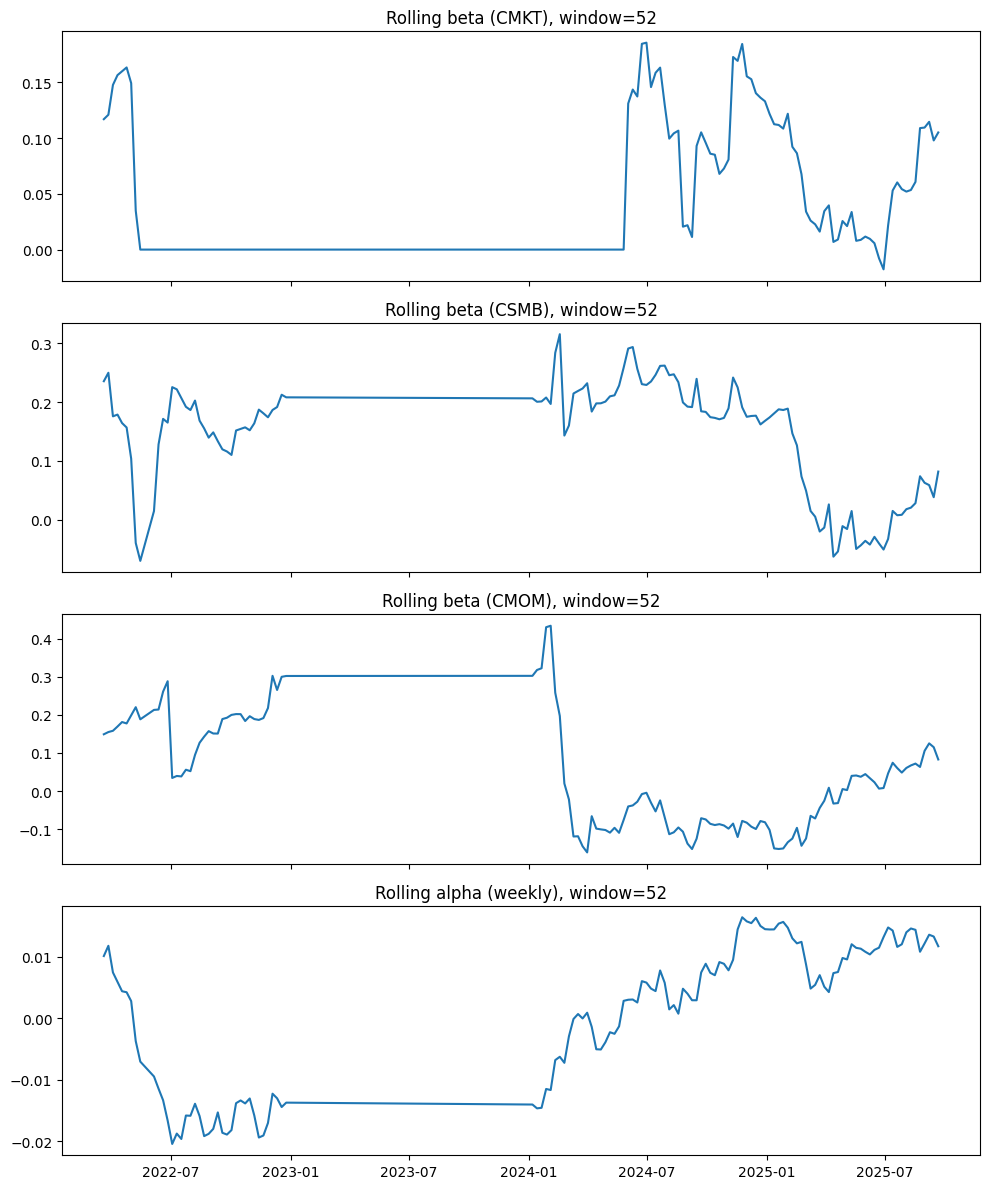

In [ ]:
# ROLLING WINDOW ANALYSIS
# Examine how factor exposures and alpha evolve over time

print("=== TIME-VARYING FACTOR ANALYSIS ===")
print(f"Rolling window: {ROLL_WIN} weeks (~{ROLL_WIN/52:.1f} years)")
print("Purpose: Detect changes in factor exposures and alpha over time")
print("Applications:")
print("- Risk management: Monitor changing exposures")
print("- Strategy adaptation: Identify regime changes")
print("- Model stability: Check parameter consistency")

def rolling_factor_reg(df, xcols, win=52, hac_lags=4):
    """
    Perform rolling factor regressions
    
    Parameters:
    - df: DataFrame with excess returns and factors
    - xcols: List of factor column names
    - win: Rolling window size in periods
    - hac_lags: Number of lags for HAC standard errors
    
    Returns:
    - DataFrame with rolling alpha and beta estimates
    """
    out = []
    for i in range(win, len(df)+1):
        sub = df.iloc[i-win:i]  # Extract rolling window
        X = sm.add_constant(sub[xcols])
        y = sub["excess"]
        try:
            r = OLS(y, X).fit(cov_type="HAC", cov_kwds={"maxlags": hac_lags})
            # Store results for this window
            row = {"date_week": sub["date_week"].iloc[-1], "alpha": r.params["const"]}
            for c in xcols:
                row[c] = r.params[c]
            out.append(row)
        except Exception:
            # Skip periods with insufficient data or numerical issues
            pass
    return pd.DataFrame(out)

# Calculate rolling factor exposures
roll = rolling_factor_reg(df_reg.assign(date_week=df_reg["date_week"]), Xcols, win=ROLL_WIN, hac_lags=HAC_LAGS)
print(f"\nRolling regression completed: {len(roll)} periods")
display(roll.tail(3))

# Visualization: Rolling Beta and Alpha Over Time
print(f"\n=== ROLLING COEFFICIENTS VISUALIZATION ===")
fig, axes = plt.subplots(len(Xcols)+1, 1, figsize=(12, 3*(len(Xcols)+1)), sharex=True)

# Plot rolling beta for each factor
for i, c in enumerate(Xcols):
    axes[i].plot(roll["date_week"], roll[c], linewidth=2, label=f'{c} exposure')
    axes[i].axhline(beta_hat[c], color='red', linestyle='--', alpha=0.7, label='Full sample β')
    axes[i].set_title(f"Rolling Beta: {c} (window={ROLL_WIN} weeks)")
    axes[i].set_ylabel('Beta')
    axes[i].legend()
    axes[i].grid(True, alpha=0.3)

# Plot rolling alpha
axes[-1].plot(roll["date_week"], roll["alpha"], linewidth=2, color='green', label='Rolling α')
axes[-1].axhline(alpha_weekly, color='red', linestyle='--', alpha=0.7, label='Full sample α')
axes[-1].axhline(0, color='black', linestyle='-', alpha=0.5, label='α = 0')
axes[-1].set_title(f"Rolling Alpha (weekly, window={ROLL_WIN})")
axes[-1].set_ylabel('Alpha')
axes[-1].set_xlabel('Date')
axes[-1].legend()
axes[-1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n=== INTERPRETATION GUIDE ===")
print("- Stable lines: Consistent factor exposures over time")
print("- Trending lines: Systematic changes in exposures")
print("- Volatile lines: Unstable or regime-dependent exposures")
print("- Alpha above/below zero: Periods of outperformance/underperformance")

In [ ]:
# SUB-PERIOD ANALYSIS
# Compare factor model results between early and late periods to detect structural changes

print("=== STRUCTURAL BREAK ANALYSIS ===")
print("Purpose: Test if factor relationships have changed over time")
print("Applications:")
print("- Market maturity: Crypto markets may have evolved")
print("- Regime changes: Bull vs bear markets")
print("- Model stability: Check robustness across periods")

# Find midpoint of the sample for splitting
mid = df_reg["date_week"].iloc[len(df_reg)//2]

def fit_subset(dmin=None, dmax=None):
    """
    Fit factor model on a subset of data
    
    Parameters:
    - dmin: Start date for subset (None = no lower bound)
    - dmax: End date for subset (None = no upper bound)
    
    Returns:
    - DataFrame with coefficient estimates, standard errors, and t-statistics
    """
    sub = df_reg.copy()
    if dmin is not None:
        sub = sub[sub["date_week"] >= dmin]
    if dmax is not None:
        sub = sub[sub["date_week"] <= dmax]
    
    X = sm.add_constant(sub[Xcols])
    y = sub["excess"]
    r = OLS(y, X).fit(cov_type="HAC", cov_kwds={"maxlags": HAC_LAGS})
    
    # Create results table
    tbl = pd.DataFrame({"coef": r.params, "se_HAC": r.bse, "t_HAC": r.tvalues})
    tbl["n"] = len(sub)
    return tbl

# Fit models for early and late periods
early = fit_subset(dmax=mid)
late  = fit_subset(dmin=mid)

print(f"\n=== PERIOD COMPARISON ===")
print(f"Split point: {mid.date()}")
print(f"Early period: {df_reg['date_week'].min().date()} to {mid.date()}")
print(f"Late period: {mid.date()} to {df_reg['date_week'].max().date()}")

print(f"\n=== EARLY PERIOD RESULTS ===")
display(early)

print(f"\n=== LATE PERIOD RESULTS ===")
display(late)

print(f"\n=== COMPARISON INTERPRETATION ===")
print("Look for:")
print("- Alpha changes: Has abnormal return generation changed?")
print("- Beta stability: Are factor exposures consistent across periods?")
print("- Significance changes: Have relationships strengthened/weakened?")
print("- Sign changes: Have any factor relationships reversed?")

# Calculate differences for key metrics
alpha_change = late.loc["const", "coef"] - early.loc["const", "coef"]
print(f"\nAlpha change (late - early): {alpha_change:.4f} weekly ({alpha_change*52:.2%} annualized)")

for factor in Xcols:
    beta_change = late.loc[factor, "coef"] - early.loc[factor, "coef"]
    print(f"{factor} beta change: {beta_change:.3f}")

Mid week: 2024-01-07
早期：


,coef,se_HAC,t_HAC,n
const,-0.000691,0.009603,-0.071939,91
CMKT,-0.000039,0.000006,-6.492327,91
CSMB,0.204847,0.114471,1.789503,91
CMOM,0.217586,0.145228,1.498237,91


後期：


,coef,se_HAC,t_HAC,n
const,0.011702,0.005866,1.994833,90
CMKT,0.109023,0.080211,1.359199,90
CSMB,0.141646,0.075883,1.866629,90
CMOM,-0.003942,0.095380,-0.041334,90


Ljung–Box Q lags=4:
     lb_stat  lb_pvalue
4  5.454291   0.243777
Ljung–Box Q lags=12:
       lb_stat  lb_pvalue
12  11.843658   0.458316


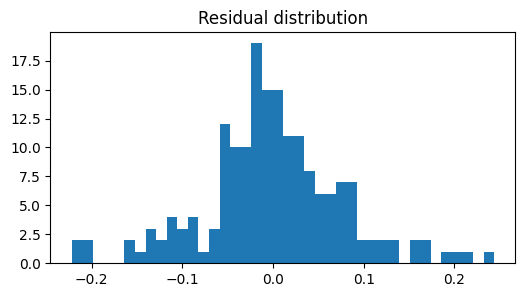

ACF (0..12): [ 1.     0.159 -0.03  -0.043  0.041  0.09   0.045  0.105  0.071 -0.047
 -0.051  0.053  0.008]


In [ ]:
# CHECKING IF OUR MODEL IS GOOD
#
# === SIMPLE EXPLANATION ===
# After building our prediction model, we need to check: "Is it actually good?"
# 
# 🎯 ARCHERY ANALOGY:
# - Good model = arrows clustered around the bullseye, random pattern
# - Bad model = arrows show systematic patterns (all to the left, or in a spiral)
#
# 🔬 WHAT WE'RE CHECKING:
# 1. Are our "misses" (residuals) random? (Good!)
# 2. Or do they show patterns we missed? (Bad!)
# 3. Are the misses normally distributed like coin flips? (Good!)

print("=== MODEL QUALITY CONTROL ===")
print("🔍 PURPOSE: Make sure our model isn't missing obvious patterns")
print("🎯 WHAT WE WANT TO SEE:")
print("   ✅ Random errors (like coin flips)")
print("   ✅ No systematic patterns in mistakes")
print("   ✅ Errors centered around zero")
print("   ✅ Roughly normal distribution of errors")
print("\n⚠️ RED FLAGS:")
print("   🔴 Errors follow patterns (we missed something!)")
print("   🔴 Errors are not random")
print("   🔴 Errors are heavily skewed or have extreme outliers")

resid = res.resid

# SERIAL CORRELATION TESTS
# TRANSLATION: "Do our mistakes follow patterns over time?"
print("\n=== PATTERN DETECTION TESTS ===")
print("🕰️ WHAT THIS CHECKS: 'Are our mistakes random over time?'")
print("🎲 GOOD SIGN: Errors are like random coin flips")
print("📈 BAD SIGN: Errors follow predictable patterns")
print("\n🧪 LJUNG-BOX TEST RESULTS:")
print("   p-value > 0.05: ✅ Random errors (good model)")
print("   p-value < 0.05: ⚠️ Patterned errors (model missed something)")

lb4  = acorr_ljungbox(resid, lags=[4], return_df=True)
lb12 = acorr_ljungbox(resid, lags=[12], return_df=True)
print("\n📊 Testing for monthly patterns (4 weeks):")
display(lb4)
print("📊 Testing for quarterly patterns (12 weeks):")
display(lb12)

# NORMALITY ASSESSMENT
print("\n=== ERROR DISTRIBUTION CHECK ===")
print("🎯 WHAT WE WANT: Errors distributed like a bell curve")
print("📊 GOOD SIGNS:")
print("   - Symmetric distribution around zero")
print("   - Most errors small, few errors large") 
print("   - Bell-shaped histogram")
print("⚠️ BAD SIGNS:")
print("   - Heavily skewed distribution")
print("   - Too many extreme outliers")

plt.figure(figsize=(12, 4))

# Histogram
plt.subplot(1, 3, 1)
plt.hist(resid, bins=40, alpha=0.7, edgecolor='black', density=True)
plt.axvline(0, color='red', linestyle='--', linewidth=2, label='Perfect (Zero)')
plt.title("📊 Error Distribution\n(Should look like a bell)")
plt.xlabel("Error Size")
plt.ylabel("Frequency")
plt.legend()

# Q-Q plot for normality check
from scipy import stats
plt.subplot(1, 3, 2)
stats.probplot(resid, dist="norm", plot=plt)
plt.title("🎯 Q-Q Plot\n(Should follow diagonal line)")
plt.grid(True, alpha=0.3)

# Box plot
plt.subplot(1, 3, 3)
plt.boxplot(resid)
plt.title("📦 Error Summary\n(Outliers as dots)")
plt.ylabel("Error Size")

plt.tight_layout()
plt.show()

# AUTOCORRELATION FUNCTION
print("\n=== DETAILED PATTERN ANALYSIS ===")
print("🔍 AUTOCORRELATION: How much do errors 'remember' previous errors?")
print("🎯 IDEAL: All values close to zero (no memory)")

from statsmodels.tsa.stattools import acf
acf_vals = acf(resid, nlags=12, fft=True)
print("📊 Memory test (12 weeks back):", np.round(acf_vals, 3))

# Interpretation guide
significant_lags = np.where(np.abs(acf_vals[1:]) > 0.1)[0] + 1  # Skip lag 0
if len(significant_lags) > 0:
    print(f"⚠️  POTENTIAL ISSUE: Strong memory detected at weeks: {significant_lags}")
    print("   This suggests our model might be missing some patterns")
else:
    print("✅ GOOD: No strong memory patterns detected")

# RESIDUAL STATISTICS SUMMARY
print(f"\n=== ERROR SUMMARY REPORT ===")
print(f"📊 Average error: {resid.mean():.6f} (should be ≈ 0)")
print(f"📏 Error spread: {resid.std():.4f}")
print(f"⚖️ Skewness: {stats.skew(resid):.3f} (should be ≈ 0 for symmetric)")
print(f"📈 Kurtosis: {stats.kurtosis(resid):.3f} (should be ≈ 0 for normal)")
print(f"📉 Range: {resid.min():.4f} to {resid.max():.4f}")

# Overall assessment
mean_close_to_zero = abs(resid.mean()) < 0.001
skew_acceptable = abs(stats.skew(resid)) < 1.0
no_strong_autocorr = len(significant_lags) == 0

print(f"\n=== OVERALL MODEL HEALTH CHECK ===")
print(f"✅ Errors centered at zero: {'Yes' if mean_close_to_zero else 'No'}")
print(f"✅ Reasonably symmetric: {'Yes' if skew_acceptable else 'No'}")
print(f"✅ No obvious patterns: {'Yes' if no_strong_autocorr else 'No'}")

if mean_close_to_zero and skew_acceptable and no_strong_autocorr:
    print("🎉 VERDICT: Model looks healthy!")
else:
    print("⚠️ VERDICT: Model may need improvement")

In [ ]:
# ANALYZING ALL CRYPTOCURRENCIES AT ONCE
#
# === SIMPLE EXPLANATION ===
# So far we analyzed one cryptocurrency. Now let's test our model on ALL of them!
#
# 🏫 SCHOOL ANALOGY:
# Instead of just testing if one student is above average, we'll test ALL students
# in the school and see which ones are truly exceptional.
#
# ⚠️ THE MULTIPLE TESTING PROBLEM:
# If you flip a coin 100 times, you might get 7 heads in a row just by luck.
# Similarly, if we test 100 cryptocurrencies, some will look "special" just by chance.
# We need to adjust for this "multiple testing" problem.

print("=== TESTING ALL CRYPTOCURRENCIES ===")
print("🎯 GOAL: Find which cryptocurrencies have genuine 'alpha' (special performance)")
print("📊 CHALLENGE: When testing many things, some look special just by luck")
print("🔬 SOLUTION: Use statistical corrections for multiple testing")
print("\n🎰 LOTTERY ANALOGY:")
print("   Testing 1 crypto for alpha = buying 1 lottery ticket")
print("   Testing 100 cryptos = buying 100 tickets")
print("   → Higher chance of false 'winners' just by luck!")
print("   → Need to be more strict about what counts as 'winning'")

# Control flag - set to True to run computationally intensive batch analysis
RUN_BATCH = False  # Change to True to enable batch processing

def single_factor_model(series_df, factors_df, hac_lags=4):
    """
    Test our factor model on a single cryptocurrency
    
    SIMPLE EXPLANATION:
    Take one cryptocurrency's price history and see if our 3-factor model
    can explain its performance, or if it has special "alpha"
    """
    # Merge asset returns with factor data
    df = series_df.merge(factors_df, on="date_week", how="inner").dropna(subset=["ret"] + Xcols)
    df["excess"] = df["ret"] - df.get("rf_weekly", 0.0)
    
    # Fit factor model
    X = sm.add_constant(df[Xcols])
    y = df["excess"]
    r = OLS(y, X).fit(cov_type="HAC", cov_kwds={"maxlags": hac_lags})
    return r

if RUN_BATCH:
    print("\n🔄 RUNNING MASS ANALYSIS...")
    print("⏱️ This analyzes every cryptocurrency individually")
    print("🧮 For each crypto, we calculate its 'alpha' (special performance)")
    print("📊 Then we rank them to find the most exceptional ones")
    
    results = []
    
    # Loop through each cryptocurrency
    print("\n🔍 Processing cryptocurrencies...")
    for aid, g in ret.groupby(asset_key):
        # Prepare asset data
        s = g[["date_week", "ret_simple_weekly", "rf_weekly"]].rename(columns={"ret_simple_weekly":"ret"})
        
        try:
            # Fit factor model for this asset
            r = single_factor_model(s, fmp, hac_lags=HAC_LAGS)
            
            # Store key results
            results.append({
                "asset": aid, 
                "alpha": r.params["const"], 
                "alpha_t": r.tvalues["const"], 
                "n": int(r.nobs)
            })
        except Exception as e:
            # Skip assets with insufficient data or other issues
            print(f"⚠️  Skipped {aid}: Not enough data")
            pass
    
    batch = pd.DataFrame(results).dropna()
    
    # MULTIPLE TESTING CORRECTION
    print(f"\n=== SOLVING THE 'MULTIPLE TESTING' PROBLEM ===")
    print(f"🎯 SITUATION: We tested {len(batch)} cryptocurrencies for special performance")
    print("🎲 PROBLEM: Some will look 'special' just by random chance")
    print("🔬 SOLUTION: Benjamini-Hochberg correction")
    print("\n💡 WHAT THIS DOES:")
    print("   Like being more strict about what counts as 'winning'")
    print("   when you buy lots of lottery tickets")
    
    from statsmodels.stats.multitest import multipletests
    
    # Calculate two-tailed p-values from t-statistics
    pvals = 2 * (1 - sm.stats.norm.cdf(batch["alpha_t"].abs()))
    
    # Apply Benjamini-Hochberg correction at 5% FDR level
    rej, p_bh, *_ = multipletests(pvals, alpha=0.05, method="fdr_bh")
    
    batch["p_raw"] = pvals
    batch["p_bh"] = p_bh
    batch["rej_5pct"] = rej
    batch["alpha_ann"] = batch["alpha"] * 52  # Annualized alpha
    
    # Sort by FDR-corrected p-values (most significant first)
    batch_sorted = batch.sort_values("p_bh")
    
    print(f"\n=== 🏆 CRYPTOCURRENCY LEADERBOARD ===")
    print("📊 Ranked by strength of evidence for special performance")
    print("📋 Column guide:")
    print("   alpha: Weekly extra return (+ = outperforming, - = underperforming)")
    print("   alpha_ann: Yearly extra return percentage")
    print("   alpha_t: Strength of evidence (higher = more convincing)")
    print("   p_bh: Adjusted p-value (lower = more significant)")
    print("   rej_5pct: True = statistically significant at 5% level")
    
    display(batch_sorted[["asset", "alpha", "alpha_ann", "alpha_t", "p_bh", "rej_5pct", "n"]].head(20))
    
    # Summary statistics
    n_significant = batch["rej_5pct"].sum()
    n_positive_alpha = (batch_sorted["alpha"] > 0).sum()
    n_negative_alpha = (batch_sorted["alpha"] < 0).sum()
    
    print(f"\n=== 📈 SUMMARY FINDINGS ===")
    print(f"🔍 Total cryptocurrencies analyzed: {len(batch)}")
    print(f"⭐ Truly significant performers: {n_significant} ({n_significant/len(batch):.1%})")
    print(f"📈 Positive alpha cryptos: {n_positive_alpha} ({n_positive_alpha/len(batch):.1%})")
    print(f"📉 Negative alpha cryptos: {n_negative_alpha} ({n_negative_alpha/len(batch):.1%})")
    print(f"📊 Average data points per crypto: {batch['n'].mean():.0f} weeks")
    
    if n_significant > 0:
        print(f"\n🎉 INTERPRETATION:")
        print(f"   Found {n_significant} cryptocurrencies with genuine special performance!")
        print(f"   These are NOT just lucky - they show consistent patterns")
    else:
        print(f"\n🤔 INTERPRETATION:")
        print(f"   No cryptocurrencies show statistically significant alpha")
        print(f"   Most performance can be explained by the 3 factors")
    
    # Export results
    stamp = pd.Timestamp.utcnow().strftime("%Y%m%d")
    output_file = MET / f"factor_model_batch_{stamp}.csv"
    batch_sorted.to_csv(output_file, index=False)
    print(f"\n💾 Results saved to: {output_file}")
    
else:
    print("\n⏸️  BATCH ANALYSIS IS DISABLED")
    print("🔧 To run this analysis: Change RUN_BATCH = True above")
    print("⚠️  WARNING: This can take several minutes and lots of computing power")
    print("📊 It will test every single cryptocurrency in your dataset")
    print("\n💡 WHAT YOU'LL GET:")
    print("   - Ranking of all cryptos by 'alpha' (special performance)")
    print("   - Statistical significance testing with multiple testing correction")
    print("   - Clear identification of truly exceptional performers")